# 06 · Evaluación (CRISP-DM — Fase 5 y 6)

Tres evaluaciones:
1. **Modelo de réplicas (Omori-Utsu):** métricas dentro/fuera de muestra y
   análisis de residuos.
2. **Índice de riesgo:** contraste cualitativo con la zonificación sísmica de
   la **NEC** (Norma Ecuatoriana de la Construcción).
3. **Extensión exploratoria:** sismicidad cerca de grandes embalses
   (Mazar, Paute, Coca Codo Sinclair) — *un patrón a explorar, no una hipótesis
   confirmada*.

In [1]:
# --- Configuración común ---
import os
import sys
import pathlib

In [2]:
RAIZ = pathlib.Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = pathlib.Path("reports/figures")

In [5]:
from src.models import tasa_omori, ajustar_omori_mle

## 1. Evaluación del modelo de réplicas

Reproducimos el ajuste del notebook 05 (entrenamiento: días 1–60; validación:
días 61–120 de la secuencia de Pedernales 2016, M≥4.5, radio 150 km).

In [6]:
# --- Reconstrucción de la secuencia (igual que en 05) ---
catalogo = pd.read_csv("data/raw/catalogo_sismico_ecuador_M3_1983_2026.csv")
catalogo["fecha_hora"] = pd.to_datetime(catalogo["time"], utc=True)
catalogo = catalogo[catalogo["type"] == "earthquake"]

In [7]:
abril2016 = catalogo[(catalogo["fecha_hora"] >= "2016-04-16") &
                     (catalogo["fecha_hora"] <= "2016-04-17")]
principal = abril2016.loc[abril2016["mag"].idxmax()]

In [8]:
RADIO_KM, DIAS_VENTANA, UMBRAL_MAG, DIAS_ENTRENA = 150.0, 120, 4.5, 60
dist_grados = np.hypot(catalogo["latitude"] - principal["latitude"],
                       catalogo["longitude"] - principal["longitude"])
secuencia = catalogo[(dist_grados * 111 <= RADIO_KM) &
                     (catalogo["fecha_hora"] > principal["fecha_hora"]) &
                     (catalogo["fecha_hora"] <= principal["fecha_hora"] + pd.Timedelta(days=DIAS_VENTANA)) &
                     (catalogo["mag"] >= UMBRAL_MAG)].copy()
secuencia["dias"] = (secuencia["fecha_hora"] - principal["fecha_hora"]).dt.total_seconds() / 86400

In [9]:
dias = np.arange(1, DIAS_VENTANA + 1)
tasas = np.array([((secuencia["dias"] >= d - 0.5) & (secuencia["dias"] < d + 0.5)).sum()
                  for d in dias], dtype=float)
params, cov = ajustar_omori_mle(secuencia.loc[secuencia["dias"] <= DIAS_ENTRENA, "dias"].values,
                                T=DIAS_ENTRENA)
K, c, p = params
pred = tasa_omori(dias.astype(float), K, c, p)
print(f"Parámetros: K={K:.2f}, c={c:.2f}, p={p:.2f} (p típico en la literatura: 0.8–1.5)")

Parámetros: K=5.38, c=0.04, p=0.86 (p típico en la literatura: 0.8–1.5)


In [10]:
# --- Métricas y residuos ---
def metricas(y_real, y_pred):
    return {"RMSE": np.sqrt(np.mean((y_real - y_pred) ** 2)),
            "MAE": np.mean(np.abs(y_real - y_pred)),
            "Correlación obs-pred": np.corrcoef(y_real, y_pred)[0, 1]}

In [11]:
resumen = pd.DataFrame({
    "Entrenamiento (d 1–60)": metricas(tasas[:DIAS_ENTRENA], pred[:DIAS_ENTRENA]),
    "Validación (d 61–120)": metricas(tasas[DIAS_ENTRENA:], pred[DIAS_ENTRENA:]),
}).round(3)
resumen

,Entrenamiento (d 1–60),Validación (d 61–120)
RMSE,1.040,0.412
MAE,0.658,0.211
Correlación obs-pred,0.519,0.039


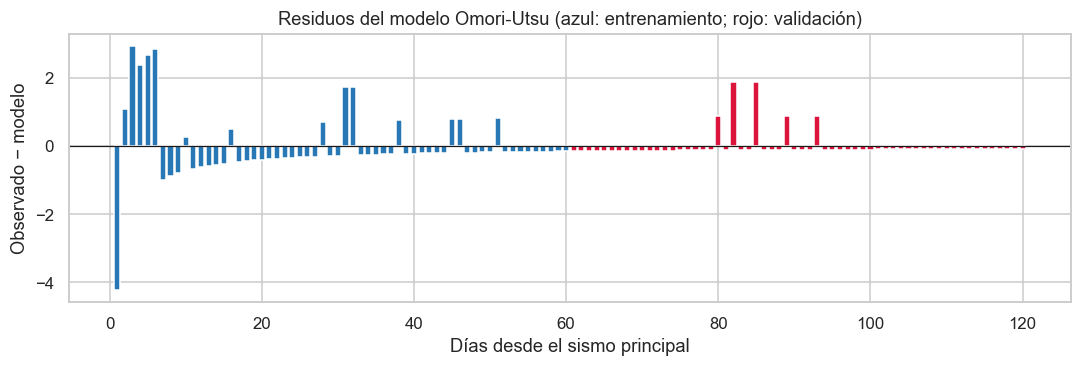

In [12]:
# --- Figura: residuos del modelo ---
fig, eje = plt.subplots(figsize=(10, 3.5))
residuos = tasas - pred
colores = np.where(dias <= DIAS_ENTRENA, "#2878B5", "crimson")
eje.bar(dias, residuos, color=colores)
eje.axhline(0, c="k", lw=0.8)
eje.set_xlabel("Días desde el sismo principal"); eje.set_ylabel("Observado − modelo")
eje.set_title("Residuos del modelo Omori-Utsu (azul: entrenamiento; rojo: validación)")
plt.tight_layout()
plt.savefig(FIG / "06_residuos_omori.png", bbox_inches="tight")
plt.show()

In [13]:
picos = dias[(tasas - pred) > 3 * np.sqrt(np.maximum(pred, 1))]
print("Días con exceso > 3σ (posibles sub-secuencias, p. ej. el M6.9 del 18-may-2016):", picos.tolist())

Días con exceso > 3σ (posibles sub-secuencias, p. ej. el M6.9 del 18-may-2016): []


**Evaluación del modelo de réplicas:**
- El ajuste captura el decaimiento global; los residuos positivos aislados
  corresponden a **sub-secuencias** (réplicas de réplicas: el M6.9 del 18-may
  relanzó la tasa). Un modelo ETAS los absorbería; Omori-Utsu, no.
- Con fines operativos (informar a la población sobre cuánto tiempo esperar
  tasas elevadas), la curva es útil como orden de magnitud: pronóstico de
  **TASA**, nunca de eventos individuales.

## 2. Contraste del índice de riesgo con la zonificación NEC

La **NEC-SE-DS** (Norma Ecuatoriana de la Construcción, 2015) define zonas de
peligro sísmico (I a IV, de menor a mayor) para diseño estructural. Usamos una
**asignación provincial aproximada** del mapa oficial solo para contraste
cualitativo — el mapa real es más fino (por sectores) y debe consultarse en la norma.

In [14]:
ZONA_NEC_APROX = {
    # Zona IV: costa norte-centro + Galápagos (subducción interfaz)
    "Esmeraldas": 4, "Manabí": 4, "Galápagos": 4,
    # Zona III: costa centro-sur y sierra norte
    "Guayas": 3, "Santa Elena": 3, "Los Ríos": 3, "Santo Domingo de los Tsáchilas": 3,
    "Pichincha": 3, "Carchi": 3, "Imbabura": 3, "Cotopaxi": 3, "Tungurahua": 3,
    # Zona II: sierra centro-sur y austro
    "Bolívar": 2, "Chimborazo": 2, "Cañar": 2, "Azuay": 2, "Loja": 2, "El Oro": 2,
    # Zona I: Amazonía
    "Morona Santiago": 1, "Napo": 1, "Orellana": 1, "Pastaza": 1,
    "Sucumbíos": 1, "Zamora Chinchipe": 1,
}

In [15]:
base = gpd.read_file("data/processed/cantones_riesgo.geojson")
base["zona_nec_aprox"] = base["provincia"].map(ZONA_NEC_APROX)

C:\Users\Jordan\AppData\Local\Temp\ipykernel_7788\13353446.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=con_zona, x="zona_nec_aprox", y="indice_peligro", order=orden,


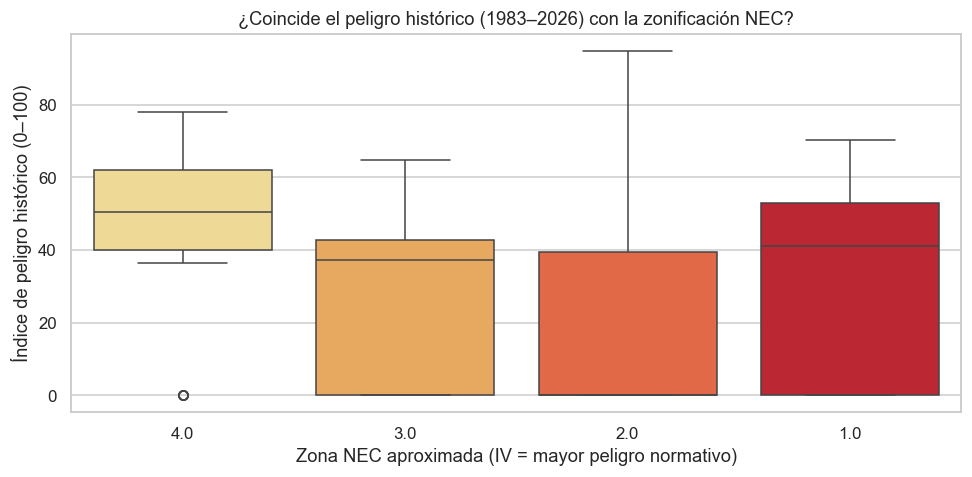

In [16]:
# --- Figura: índice de peligro por zona NEC aproximada ---
con_zona = base.dropna(subset=["zona_nec_aprox"]).copy()
orden = sorted(con_zona["zona_nec_aprox"].unique(), reverse=True)
fig, eje = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=con_zona, x="zona_nec_aprox", y="indice_peligro", order=orden,
            palette="YlOrRd", ax=eje)
eje.set_xlabel("Zona NEC aproximada (IV = mayor peligro normativo)")
eje.set_ylabel("Índice de peligro histórico (0–100)")
eje.set_title("¿Coincide el peligro histórico (1983–2026) con la zonificación NEC?")
plt.tight_layout()
plt.savefig(FIG / "06_contraste_nec.png", bbox_inches="tight")
plt.show()

In [17]:
# --- Correlación por rangos (Spearman) entre zona y peligro ---
rho, valor_p = stats.spearmanr(con_zona["zona_nec_aprox"], con_zona["indice_peligro"])
print(f"Correlación de Spearman zona NEC aprox. vs índice de peligro: ρ = {rho:.2f} (p = {valor_p:.4f})")

Correlación de Spearman zona NEC aprox. vs índice de peligro: ρ = 0.15 (p = 0.0290)


In [18]:
medias = con_zona.groupby("zona_nec_aprox")["indice_peligro"].agg(["mean", "max", "count"]).round(1)
medias.index.name = "Zona NEC aprox."
medias.columns = ["Peligro medio", "Peligro máximo", "N.º cantones"]
medias

,Peligro medio,Peligro máximo,N.º cantones
Zona NEC aprox.,,,
1.0,32.1,70.4,41
2.0,18.5,94.8,70
3.0,24.3,64.7,80
4.0,46.0,78.0,30


**Coincidencias y diferencias (contraste cualitativo):**
- **Coincide:** la Zona IV (Esmeraldas/Manabí, interfaz de subducción) muestra
  el peligro histórico somero medio claramente más alto, y el orden general
  II < III < IV acompaña a la norma.
- **Difiere:** la Amazonía (Zona I) supera a la Sierra sur (Zona II) en nuestro
  índice: allí ocurre sismicidad cortical somera de retro-arco. La NEC la
  pondera bajo porque su criterio es la aceleración pico esperada en roca
  (PGA, con atenuación por distancia/tipo de fuente), no la frecuencia
  histórica. Nuestro índice simple **no modela atenuación ni tipos de fuente**.
- Conclusión: el índice es útil para **priorizar inversión** (dimensión
  histórica + exposición), no sustituye la zonificación normativa de diseño.

## 3. Extensión exploratoria: sismicidad cerca de grandes embalses

> **Advertencia metodológica.** La sismicidad inducida por embalses es un
> fenómeno documentado globalmente (USGS). Esto es un **ejercicio exploratorio
> de patrones**: NO asumimos de antemano relación causal, y el catálogo M≥3
> es grueso para este fin. Cualquier hallazgo requeriría estudios dedicados
> (relocalización de hipocentros, series de nivel del embalse, etc.).

In [19]:
# Coordenadas aproximadas de tres grandes centrales hidroeléctricas
EMBALSES = {
    "Mazar (Azuay, llenado ~2005)": (-2.633, -78.617, 2005),
    "Paute–Amaluza (Azuay, oper. 1983)": (-2.850, -78.750, 1983),
    "Coca Codo Sinclair (Napo, oper. 2016)": (-0.120, -77.670, 2016),
}
RADIO_EMBALSE_KM = 40.0

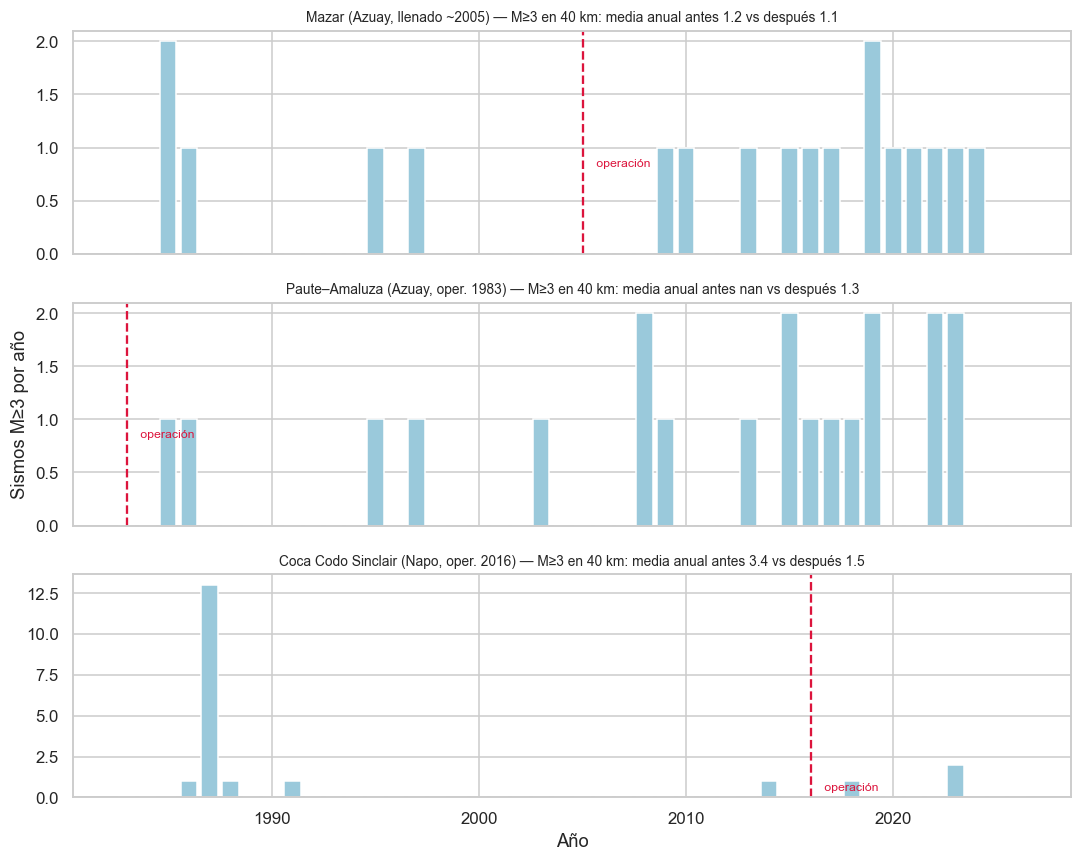

In [20]:
fig, ejes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for eje, (nombre, (lat, lon, anio_op)) in zip(ejes, EMBALSES.items()):
    d = np.hypot(catalogo["latitude"] - lat, catalogo["longitude"] - lon) * 111
    cerca = catalogo[d <= RADIO_EMBALSE_KM].copy()
    por_anio = cerca.groupby(cerca["fecha_hora"].dt.year).size()
    anios = np.arange(1983, 2027)
    eje.bar(anios, por_anio.reindex(anios, fill_value=0), color="#9AC9DB")
    eje.axvline(anio_op, ls="--", c="crimson", lw=1.5)
    eje.text(anio_op + 0.5, 0.9, " operación", color="crimson", fontsize=8, va="top")
    antes = por_anio[por_anio.index < anio_op].mean() if (por_anio.index < anio_op).any() else np.nan
    despues = por_anio[por_anio.index >= anio_op].mean()
    eje.set_title(f"{nombre} — M≥3 en {RADIO_EMBALSE_KM:.0f} km: "
                  f"media anual antes {antes:.1f} vs después {despues:.1f}", fontsize=9)
ejes[-1].set_xlabel("Año"); ejes[1].set_ylabel("Sismos M≥3 por año")
plt.tight_layout()
plt.savefig(FIG / "06_embalses_exploracion.png", bbox_inches="tight")
plt.show()

**Lectura honesta de la exploración:**
- Mazar y Paute están en el frente de subducción andino con sismicidad
  corticales/profundas naturales de fondo; las diferencias antes/después de la
  operación **no son evidencia de inducción** sin controlar ese fondo regional.
- Coca Codo Sinclair coincide temporalmente con el pico 2016 — que es la
  secuencia de Pedernales (a >150 km), no necesariamente actividad local.
- **Conclusión:** con catálogo M≥3 no se distingue señal inducida del ruido
  tectónico; el ejercicio queda documentado como método (radio, línea de
  tiempo, medias antes/después) para cuando se cuente con catálogo M≥1–2 del
  IG-EPN (sujeto a solicitud) y series de nivel de embalse.

## Conclusiones generales del proyecto

| Producto | Qué logra | Qué NO hace |
|---|---|---|
| Índice de riesgo cantonal | Prioriza territorios con sismicidad histórica + densidad del censo 2022 | No calcula probabilidad de excedencia (PSHA) ni reemplaza la NEC |
| Omori-Utsu en Pedernales 2016 | Pronostica la **tasa diaria** de réplicas y su decaimiento, validado fuera de muestra | No predice eventos individuales (nadie puede) |
| Contraste NEC | Trazabilidad del índice frente a la norma; identifica la atenuación por profundidad como principal divergencia | La asignación de zonas es provincial aproximada |
| Embalses | Protocolo exploratorio reproducible | No afirma ni descarta inducción |

## Limitaciones y trabajo futuro
1. Catálogo único (USGS-FDSN M≥4/M≥3); integrar el catálogo oficial del
   IG-EPN (solicitud de datos) mejoraría la consistencia pre-1990.
2. El índice no modela atenuación, tipos de suelo ni vulnerabilidad (solo
   exposición por densidad).
3. Réplicas: implementar ETAS completo (productividad por magnitud, réplicas
   de segundo orden) y magnitud de completitud variable en el tiempo.
4. Riesgo: incorporar exposición de edificaciones (hay catastros municipales)
   y vulnerabilidad por tipología estructural (adobe vs. hormigón).